In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

from config import *

In [2]:
df = pd.read_parquet("../data/score_dataset_48h.parquet")
df.sample(n=5)

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance
68538,rn1qkbnr/ppp1pppp/8/3p1b2/3P1B2/5N2/PPP1PPPP/R...,e7e6,1216,False,2681,e7e6,-20.0,0.158065,2296.272038
152419,r2qkbnr/ppp1pppp/2n5/3p1b2/3P1B2/4P3/PPP2PPP/R...,f1b5,1378,False,544,c2c4,-29.0,0.121505,18682.848706
601889,rnbqkbnr/ppp2ppp/8/3pp3/3P1B2/4P3/PPP2PPP/RN1Q...,e5f4,763,False,242,e5f4,8.0,0.034483,392.566282
789406,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1701,False,145903,g8f6,-8.0,0.025806,107.640847
66872,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,b8c6,1424,False,43197,e7e6,-34.0,0.156989,1046.628895


In [3]:
scaler = StandardScaler()
df[FEATURES] = scaler.fit_transform(df[FEATURES])

elo_stats = pd.DataFrame(index=ELOS, columns=FEATURES, dtype=float)

for elo in ELOS:
    mask = df["played_by_elo"].between(elo - ELO_DEV, elo + ELO_DEV)
    group = df.loc[mask, FEATURES]
    elo_stats.loc[elo, :] = group.mean().values

elo_stats

,delta,fragility_score,variance
1000,-0.068845,0.069215,0.017551
1100,-0.055733,0.071551,0.013641
1200,-0.035786,0.057256,0.005732
1300,-0.015990,0.041484,0.002582
1400,-0.002344,0.028501,0.000472
1500,0.009989,0.011386,-0.007275
1600,0.021596,-0.009804,-0.011705
1700,0.031465,-0.038358,-0.009670
1800,0.034386,-0.058955,-0.004807
1900,0.035352,-0.062744,-0.003589


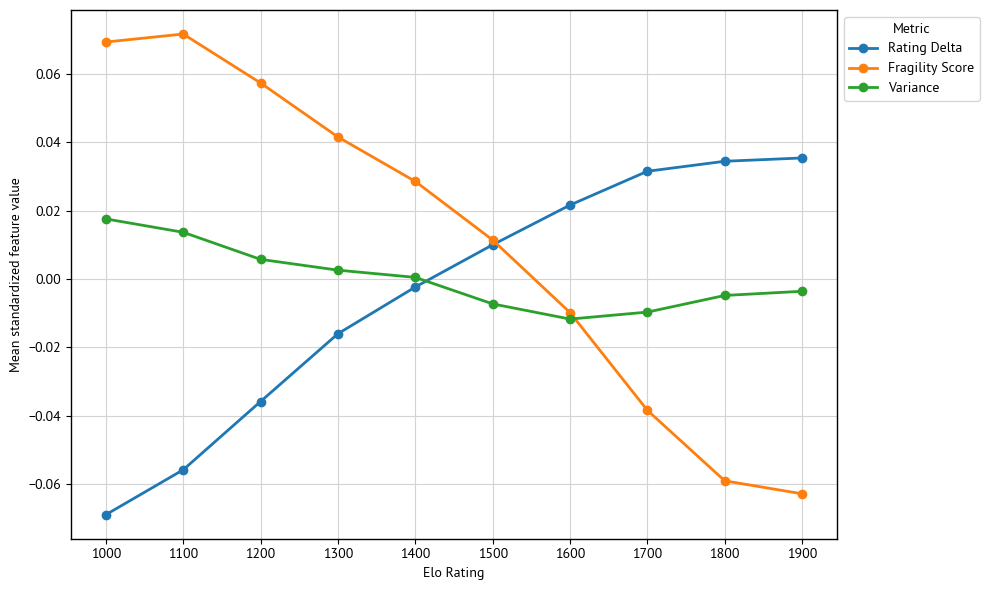

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = elo_stats[feature].values
    plt.plot(elo_stats.index, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Mean standardized feature value")
plt.xticks(elo_stats.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_means.pdf")
plt.show()